In [ ]:
!wget https://www.kinfacew.com/dataset/KinFaceW-I.zip

--2025-01-18 19:03:05--  https://www.kinfacew.com/dataset/KinFaceW-I.zip
Resolving www.kinfacew.com (www.kinfacew.com)... 46.17.172.215, 2a02:4780:3:1337:0:dad:21e4:2
Connecting to www.kinfacew.com (www.kinfacew.com)|46.17.172.215|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2383840 (2.3M) [application/zip]
Saving to: ‘KinFaceW-I.zip.1’

KinFaceW-I.zip.1    100%[===================>]   2.27M  1.49MB/s    in 1.5s    

2025-01-18 19:03:07 (1.49 MB/s) - ‘KinFaceW-I.zip.1’ saved [2383840/2383840]



In [ ]:
!unzip /content/KinFaceW-I.zip -d /content/datasets

Archive:  /content/KinFaceW-I.zip
replace /content/datasets/KinFaceW-I/images/father-dau/fd_001_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!wget https://www.kinfacew.com/dataset/KinFaceW-II.zip

--2025-01-18 16:53:00--  https://www.kinfacew.com/dataset/KinFaceW-II.zip
Resolving www.kinfacew.com (www.kinfacew.com)... 46.17.172.215, 2a02:4780:3:1337:0:dad:21e4:2
Connecting to www.kinfacew.com (www.kinfacew.com)|46.17.172.215|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4355982 (4.2M) [application/zip]
Saving to: ‘KinFaceW-II.zip’

KinFaceW-II.zip     100%[===================>]   4.15M  2.38MB/s    in 1.7s    

2025-01-18 16:53:03 (2.38 MB/s) - ‘KinFaceW-II.zip’ saved [4355982/4355982]



In [ ]:
!unzip /content/KinFaceW-II.zip -d /content/datasets

Archive:  /content/KinFaceW-II.zip
   creating: /content/datasets/KinFaceW-II/images/
   creating: /content/datasets/KinFaceW-II/images/father-dau/
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_001_1.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_001_2.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_002_1.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_002_2.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_003_1.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_003_2.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_004_1.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_004_2.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_005_1.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_005_2.jpg  
  inflating: /content/datasets/KinFaceW-II/images/father-dau/fd_006_1.jpg  
  inflating: /co

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%ls "/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files"

FIW_buffalo_sc_faces_info.pkl          KinFaceW-II_faces_info.pkl
KinFaceW-I_buffalo_sc_faces_info.pkl   SiblingsDB_buffalo_sc_faces_info.pkl
KinFaceW-I_faces_info.pkl              SiblingsDB_faces_info.pkl
KinFaceW-II_buffalo_sc_faces_info.pkl


In [ ]:
import pickle

with open("/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files/KinFaceW-I_buffalo_sc_faces_info.pkl", "rb") as f:
  buffalo_sc_embeddings_I = pickle.load(f)
with open("/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files/KinFaceW-II_buffalo_sc_faces_info.pkl", "rb") as f:
  buffalo_sc_embeddings_II = pickle.load(f)

In [ ]:
with open("/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files/KinFaceW-I_faces_info.pkl", "rb") as f:
  buffalo_l_embeddings_I = pickle.load(f)
with open("/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files/KinFaceW-II_faces_info.pkl", "rb") as f:
  buffalo_l_embeddings_II = pickle.load(f)

In [ ]:
list(buffalo_l_embeddings_I.keys())[:10]

['/content/datasets/KinFaceW-I/images/father-dau/fd_094_2.jpg',
 '/content/datasets/KinFaceW-I/images/mother-dau/md_122_1.jpg',
 '/content/datasets/KinFaceW-I/images/mother-son/ms_103_2.jpg',
 '/content/datasets/KinFaceW-I/images/mother-son/ms_089_1.jpg',
 '/content/datasets/KinFaceW-I/images/mother-dau/md_116_2.jpg',
 '/content/datasets/KinFaceW-I/images/mother-son/ms_093_2.jpg',
 '/content/datasets/KinFaceW-I/images/father-dau/fd_020_1.jpg',
 '/content/datasets/KinFaceW-I/images/father-son/fs_118_2.jpg',
 '/content/datasets/KinFaceW-I/images/father-son/fs_072_2.jpg',
 '/content/datasets/KinFaceW-I/images/mother-son/ms_067_2.jpg']

In [ ]:
import os
from os.path import join
import scipy.io

pairs_I = dict()
for kinship_type in os.listdir('/content/datasets/KinFaceW-I/images'):
    print(kinship_type)
    kinship_abbreviated = kinship_type[0] + kinship_type[kinship_type.find('-') + 1]
    mat = scipy.io.loadmat(join('/content/datasets/KinFaceW-I/meta_data', f"{kinship_abbreviated}_pairs.mat"))
    pairs_I[kinship_type] = []
    for el in mat["pairs"]:
        pairs_I[kinship_type].append((el[0][0][0], el[1][0][0], el[2][0], el[3][0]))

father-dau
mother-dau
mother-son
father-son


In [ ]:
pairs_I

{'father-dau': [(1, 1, 'fd_024_1.jpg', 'fd_024_2.jpg'),
  (1, 1, 'fd_092_1.jpg', 'fd_092_2.jpg'),
  (1, 1, 'fd_124_1.jpg', 'fd_124_2.jpg'),
  (1, 1, 'fd_031_1.jpg', 'fd_031_2.jpg'),
  (1, 1, 'fd_008_1.jpg', 'fd_008_2.jpg'),
  (1, 1, 'fd_042_1.jpg', 'fd_042_2.jpg'),
  (1, 1, 'fd_120_1.jpg', 'fd_120_2.jpg'),
  (1, 1, 'fd_021_1.jpg', 'fd_021_2.jpg'),
  (1, 1, 'fd_118_1.jpg', 'fd_118_2.jpg'),
  (1, 1, 'fd_099_1.jpg', 'fd_099_2.jpg'),
  (1, 1, 'fd_091_1.jpg', 'fd_091_2.jpg'),
  (1, 1, 'fd_025_1.jpg', 'fd_025_2.jpg'),
  (1, 1, 'fd_055_1.jpg', 'fd_055_2.jpg'),
  (1, 1, 'fd_085_1.jpg', 'fd_085_2.jpg'),
  (1, 1, 'fd_015_1.jpg', 'fd_015_2.jpg'),
  (1, 1, 'fd_050_1.jpg', 'fd_050_2.jpg'),
  (1, 1, 'fd_051_1.jpg', 'fd_051_2.jpg'),
  (1, 1, 'fd_027_1.jpg', 'fd_027_2.jpg'),
  (1, 1, 'fd_030_1.jpg', 'fd_030_2.jpg'),
  (1, 1, 'fd_094_1.jpg', 'fd_094_2.jpg'),
  (1, 1, 'fd_039_1.jpg', 'fd_039_2.jpg'),
  (1, 1, 'fd_026_1.jpg', 'fd_026_2.jpg'),
  (1, 1, 'fd_111_1.jpg', 'fd_111_2.jpg'),
  (1, 1, 'fd_131_1.j

In [ ]:
pairs_II = dict()
for kinship_type in os.listdir('/content/datasets/KinFaceW-II/images'):
    print(kinship_type)
    kinship_abbreviated = kinship_type[0] + kinship_type[kinship_type.find('-') + 1]
    mat = scipy.io.loadmat(join('/content/datasets/KinFaceW-II/meta_data', f"{kinship_abbreviated}_pairs.mat"))
    pairs_II[kinship_type] = []
    for el in mat["pairs"]:
        pairs_II[kinship_type].append((el[0][0][0], el[1][0][0], el[2][0], el[3][0]))

father-dau
mother-dau
mother-son
father-son


In [ ]:
import pandas as pd


fold_list = []
kinship_list = []
image1_list = []
image2_list = []
kinship_type_list = []
for k, v in pairs_I.items():
    for el in v:
        fold_list.append(el[0])
        kinship_list.append(el[1])
        image1_list.append(f"{k}/{el[2]}")
        image2_list.append(f"{k}/{el[3]}")
        kinship_type_list.append(k)
df_I = pd.DataFrame(list(zip(fold_list, kinship_list, image1_list, image2_list, kinship_type_list)), columns=["fold", "kinship", "image1", "image2", "kinship_type"])
df_I

,fold,kinship,image1,image2,kinship_type
0,1,1,father-dau/fd_024_1.jpg,father-dau/fd_024_2.jpg,father-dau
1,1,1,father-dau/fd_092_1.jpg,father-dau/fd_092_2.jpg,father-dau
2,1,1,father-dau/fd_124_1.jpg,father-dau/fd_124_2.jpg,father-dau
3,1,1,father-dau/fd_031_1.jpg,father-dau/fd_031_2.jpg,father-dau
4,1,1,father-dau/fd_008_1.jpg,father-dau/fd_008_2.jpg,father-dau
...,...,...,...,...,...
1061,5,0,father-son/fs_143_1.jpg,father-son/fs_017_2.jpg,father-son
1062,5,0,father-son/fs_143_1.jpg,father-son/fs_086_2.jpg,father-son
1063,5,0,father-son/fs_013_1.jpg,father-son/fs_023_2.jpg,father-son
1064,5,0,father-son/fs_041_1.jpg,father-son/fs_005_2.jpg,father-son


In [ ]:
fold_list = []
kinship_list = []
image1_list = []
image2_list = []
kinship_type_list = []
for k, v in pairs_II.items():
    for el in v:
        fold_list.append(el[0])
        kinship_list.append(el[1])
        image1_list.append(f"{k}/{el[2]}")
        image2_list.append(f"{k}/{el[3]}")
        kinship_type_list.append(k)
df_II = pd.DataFrame(list(zip(fold_list, kinship_list, image1_list, image2_list, kinship_type_list)), columns=["fold", "kinship", "image1", "image2", "kinship_type"])
df_II

,fold,kinship,image1,image2,kinship_type
0,1,1,father-dau/fd_240_1.jpg,father-dau/fd_240_2.jpg,father-dau
1,1,1,father-dau/fd_024_1.jpg,father-dau/fd_024_2.jpg,father-dau
2,1,1,father-dau/fd_220_1.jpg,father-dau/fd_220_2.jpg,father-dau
3,1,1,father-dau/fd_092_1.jpg,father-dau/fd_092_2.jpg,father-dau
4,1,1,father-dau/fd_155_1.jpg,father-dau/fd_155_2.jpg,father-dau
...,...,...,...,...,...
1995,5,0,father-son/fs_234_1.jpg,father-son/fs_009_2.jpg,father-son
1996,5,0,father-son/fs_143_1.jpg,father-son/fs_005_2.jpg,father-son
1997,5,0,father-son/fs_089_1.jpg,father-son/fs_100_2.jpg,father-son
1998,5,0,father-son/fs_041_1.jpg,father-son/fs_123_2.jpg,father-son


In [ ]:
df_I.to_csv("/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files/KinFaceW-I_pairs.csv")
df_II.to_csv("/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files/KinFaceW-II_pairs.csv")

In [ ]:
from scipy.spatial.distance import cosine

def get_distance(image1, image2, embeddings, prefix):
    image1 = prefix + image1
    image2 = prefix + image2
    if embeddings[image1] is None or embeddings[image2] is None:
        return None
    return cosine(embeddings[image1]["embedding"], embeddings[image2]["embedding"])


df_I["buffalo_l_cosine_distance"] = df_I.apply(lambda x: get_distance(x["image1"], x["image2"], buffalo_l_embeddings_I, "/content/datasets/KinFaceW-I/images/"), axis=1)
df_I["buffalo_sc_cosine_distance"] = df_I.apply(lambda x: get_distance(x["image1"], x["image2"], buffalo_sc_embeddings_I, "/content/datasets/KinFaceW-I/images/"), axis=1)
df_I

,fold,kinship,image1,image2,kinship_type,buffalo_l_cosine_distance,buffalo_sc_cosine_distance
0,1,1,father-dau/fd_024_1.jpg,father-dau/fd_024_2.jpg,father-dau,0.871219,0.775106
1,1,1,father-dau/fd_092_1.jpg,father-dau/fd_092_2.jpg,father-dau,0.789346,0.764378
2,1,1,father-dau/fd_124_1.jpg,father-dau/fd_124_2.jpg,father-dau,0.960439,1.026986
3,1,1,father-dau/fd_031_1.jpg,father-dau/fd_031_2.jpg,father-dau,0.835913,0.748104
4,1,1,father-dau/fd_008_1.jpg,father-dau/fd_008_2.jpg,father-dau,0.991587,1.017902
...,...,...,...,...,...,...,...
1061,5,0,father-son/fs_143_1.jpg,father-son/fs_017_2.jpg,father-son,1.093727,0.958367
1062,5,0,father-son/fs_143_1.jpg,father-son/fs_086_2.jpg,father-son,0.980794,0.877744
1063,5,0,father-son/fs_013_1.jpg,father-son/fs_023_2.jpg,father-son,0.973102,0.816424
1064,5,0,father-son/fs_041_1.jpg,father-son/fs_005_2.jpg,father-son,1.072170,0.939540


In [ ]:
df_I["buffalo_l_cosine_distance"].isna().sum(), df_I["buffalo_sc_cosine_distance"].isna().sum()

(0, 13)

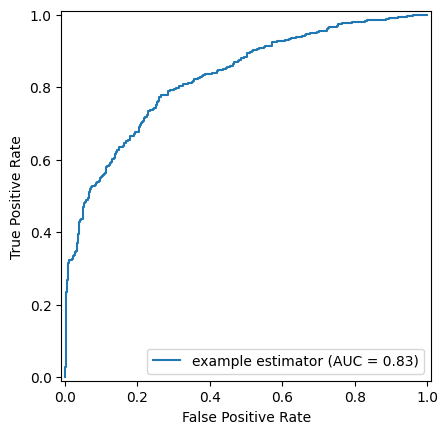

In [ ]:
from sklearn import metrics


df_non_empty = df_I[df_I["buffalo_sc_cosine_distance"].notna()]
y = df_non_empty['kinship']
pred = -df_non_empty["buffalo_sc_cosine_distance"]


fpr, tpr, thresholds = metrics.roc_curve(y, pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()

<Axes: xlabel='buffalo_sc_cosine_distance', ylabel='Count'>

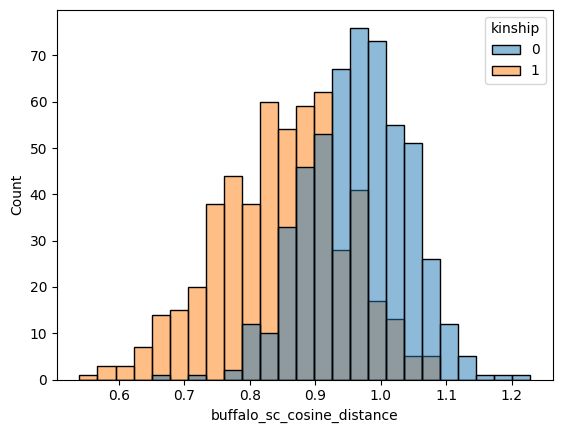

In [ ]:
import seaborn as sns

sns.histplot(data=df_I, x="buffalo_sc_cosine_distance", hue="kinship")

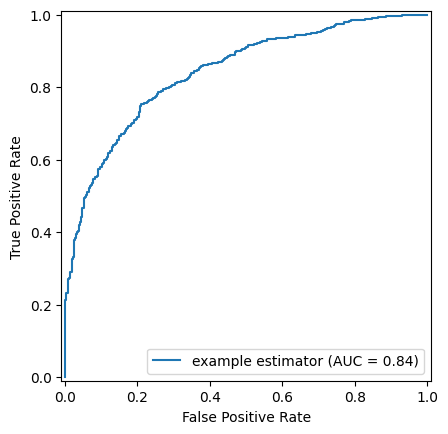

In [ ]:
df_non_empty = df_I[df_I["buffalo_l_cosine_distance"].notna()]
y = df_non_empty['kinship']
pred = -df_non_empty["buffalo_l_cosine_distance"]


fpr, tpr, thresholds = metrics.roc_curve(y, pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()

<Axes: xlabel='buffalo_l_cosine_distance', ylabel='Count'>

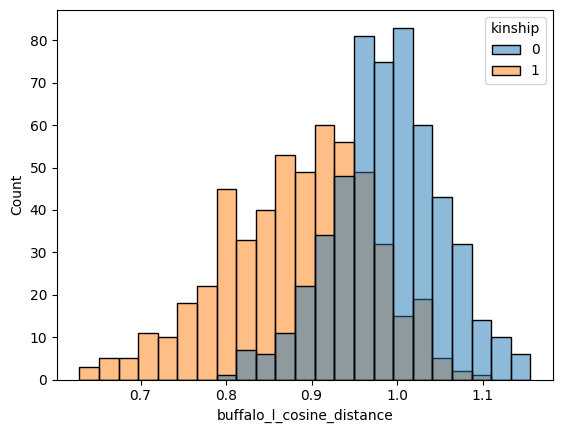

In [ ]:
sns.histplot(data=df_I, x="buffalo_l_cosine_distance", hue="kinship")

In [ ]:
from scipy.spatial.distance import cosine

def get_distance(image1, image2, embeddings, prefix):
    image1 = prefix + image1
    image2 = prefix + image2
    if embeddings[image1] is None or embeddings[image2] is None:
        return None
    return cosine(embeddings[image1]["embedding"], embeddings[image2]["embedding"])


df_II["buffalo_l_cosine_distance"] = df_II.apply(lambda x: get_distance(x["image1"], x["image2"], buffalo_l_embeddings_II, "/content/datasets/KinFaceW-II/images/"), axis=1)
df_II["buffalo_sc_cosine_distance"] = df_II.apply(lambda x: get_distance(x["image1"], x["image2"], buffalo_sc_embeddings_II, "/content/datasets/KinFaceW-II/images/"), axis=1)
df_II

,fold,kinship,image1,image2,kinship_type,buffalo_l_cosine_distance,buffalo_sc_cosine_distance
0,1,1,father-dau/fd_240_1.jpg,father-dau/fd_240_2.jpg,father-dau,1.007369,0.946934
1,1,1,father-dau/fd_024_1.jpg,father-dau/fd_024_2.jpg,father-dau,0.971549,0.977787
2,1,1,father-dau/fd_220_1.jpg,father-dau/fd_220_2.jpg,father-dau,0.902440,NaN
3,1,1,father-dau/fd_092_1.jpg,father-dau/fd_092_2.jpg,father-dau,1.045552,0.931874
4,1,1,father-dau/fd_155_1.jpg,father-dau/fd_155_2.jpg,father-dau,0.970972,0.977817
...,...,...,...,...,...,...,...
1995,5,0,father-son/fs_234_1.jpg,father-son/fs_009_2.jpg,father-son,0.992262,0.927633
1996,5,0,father-son/fs_143_1.jpg,father-son/fs_005_2.jpg,father-son,1.046692,0.972309
1997,5,0,father-son/fs_089_1.jpg,father-son/fs_100_2.jpg,father-son,0.956903,0.970701
1998,5,0,father-son/fs_041_1.jpg,father-son/fs_123_2.jpg,father-son,1.019902,1.068749


In [ ]:
df_II["buffalo_l_cosine_distance"].isna().sum(), df_II["buffalo_sc_cosine_distance"].isna().sum()

(0, 96)

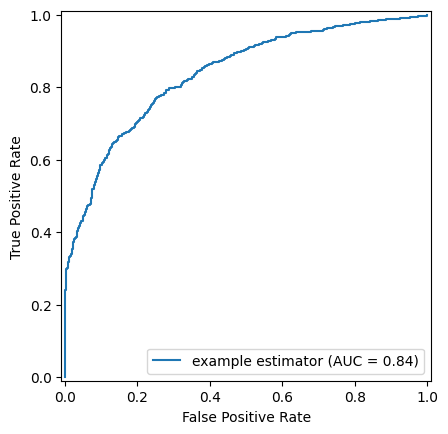

In [ ]:
df_non_empty = df_II[df_II["buffalo_sc_cosine_distance"].notna()]
y = df_non_empty['kinship']
pred = -df_non_empty["buffalo_sc_cosine_distance"]


fpr, tpr, thresholds = metrics.roc_curve(y, pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()

<Axes: xlabel='buffalo_sc_cosine_distance', ylabel='Count'>

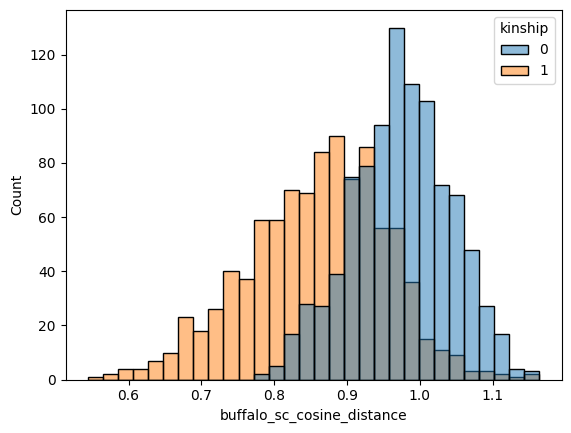

In [ ]:
sns.histplot(data=df_II, x="buffalo_sc_cosine_distance", hue="kinship")

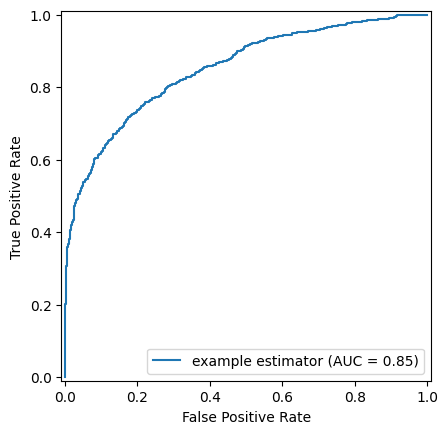

In [ ]:
df_non_empty = df_II[df_II["buffalo_l_cosine_distance"].notna()]
y = df_non_empty['kinship']
pred = -df_non_empty["buffalo_l_cosine_distance"]


fpr, tpr, thresholds = metrics.roc_curve(y, pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()

<Axes: xlabel='buffalo_l_cosine_distance', ylabel='Count'>

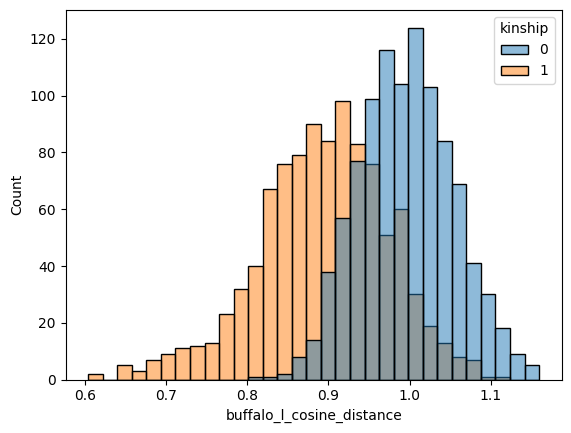

In [ ]:
sns.histplot(data=df_II, x="buffalo_l_cosine_distance", hue="kinship")

In [ ]:
from sklearn.metrics import roc_curve
import numpy as np


def get_matrix_values(y_score, y_true):
    ###
    # Compute the TPR and FPR for different thresholds
    ###
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    ###
    # Calculate the number of positive and negative samples
    ###
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    ###
    # Compute TP, TN, FP, and FN for each threshold
    ###
    tps = tpr * P
    tns = (1 - fpr) * N
    fps = fpr * N
    fns = P - tps



    return tps, fps, tns, fns, thresholds #if score >= threshold, we assign the class 1


def get_accuracy_curve(y_score, y_true):
    tps, fps, tns, fns, thresholds = get_matrix_values(y_score, y_true)
    accuracy = (tps + tns) / (tps + tns + fns + fps)
    return accuracy, thresholds


def cross_validation(df, distance_column):
  accuracy_list = []
  for fold in df["fold"].unique():
    train_df = df[df["fold"] != fold].copy()
    test_df = df[df["fold"] == fold].copy()
    median_value = train_df[distance_column].median()
    train_df[distance_column] = train_df[distance_column].fillna(median_value)
    test_df[distance_column] = test_df[distance_column].fillna(median_value)

    y_train = train_df['kinship']
    y_score = np.array(train_df[distance_column])

    accuracies, thresholds = get_accuracy_curve(-y_score, np.array(y_train))

    best_accuracy = max(accuracies)
    best_threshold = -max(zip(accuracies, thresholds), key = lambda x: x[0])[1]

    print(f"Fold {fold} best train accuracy: {best_accuracy}, best threshold: {best_threshold}")

    y_test = test_df['kinship']
    y_score = np.array(test_df[distance_column])
    y_pred = np.array(y_score < best_threshold, dtype=int)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    accuracy_list.append(accuracy)
    print(f"Fold {fold} test accuracy: {accuracy}")

  return np.mean(accuracy_list)

In [ ]:
cross_validation(df_I, "buffalo_l_cosine_distance")

Fold 1 best train accuracy: 0.7775175644028103, best threshold: 0.9448808749604724
Fold 1 test accuracy: 0.75
Fold 2 best train accuracy: 0.7704918032786885, best threshold: 0.9448808749604724
Fold 2 test accuracy: 0.7783018867924528
Fold 3 best train accuracy: 0.7646370023419203, best threshold: 0.9448808749604724
Fold 3 test accuracy: 0.8018867924528302
Fold 4 best train accuracy: 0.7786885245901639, best threshold: 0.9442168800160317
Fold 4 test accuracy: 0.7358490566037735
Fold 5 best train accuracy: 0.7688679245283019, best threshold: 0.9448808749604724
Fold 5 test accuracy: 0.7844036697247706


0.7700882811147653

In [ ]:
cross_validation(df_I, "buffalo_sc_cosine_distance")

Fold 1 best train accuracy: 0.7587822014051522, best threshold: 0.9184966092872181
Fold 1 test accuracy: 0.7311320754716981
Fold 2 best train accuracy: 0.7494145199063232, best threshold: 0.9157618130543702
Fold 2 test accuracy: 0.7641509433962265
Fold 3 best train accuracy: 0.7517564402810304, best threshold: 0.9159122795999303
Fold 3 test accuracy: 0.7594339622641509
Fold 4 best train accuracy: 0.7599531615925058, best threshold: 0.9184966092872181
Fold 4 test accuracy: 0.7264150943396226
Fold 5 best train accuracy: 0.75, best threshold: 0.9085322822623141
Fold 5 test accuracy: 0.7477064220183486


0.7457676994980094

In [ ]:
cross_validation(df_II, "buffalo_l_cosine_distance")

Fold 1 best train accuracy: 0.774375, best threshold: 0.9369507531182104
Fold 1 test accuracy: 0.755
Fold 2 best train accuracy: 0.766875, best threshold: 0.9394156161934525
Fold 2 test accuracy: 0.7875
Fold 3 best train accuracy: 0.77625, best threshold: 0.9494562618696042
Fold 3 test accuracy: 0.74
Fold 4 best train accuracy: 0.77625, best threshold: 0.9495266623224988
Fold 4 test accuracy: 0.7425
Fold 5 best train accuracy: 0.7675, best threshold: 0.9301630289534716
Fold 5 test accuracy: 0.77


0.759

In [ ]:
cross_validation(df_II, "buffalo_sc_cosine_distance")

Fold 1 best train accuracy: 0.744375, best threshold: 0.9277638539921139
Fold 1 test accuracy: 0.765
Fold 2 best train accuracy: 0.741875, best threshold: 0.9002245711068756
Fold 2 test accuracy: 0.7625
Fold 3 best train accuracy: 0.750625, best threshold: 0.9031917139597506
Fold 3 test accuracy: 0.735
Fold 4 best train accuracy: 0.76, best threshold: 0.9278838764258629
Fold 4 test accuracy: 0.705
Fold 5 best train accuracy: 0.75125, best threshold: 0.9259044919930027
Fold 5 test accuracy: 0.7275


0.739

The results can be compared to the ones here: https://www.kinfacew.com/results.html